# Wind Production Scenario Generator — Conditional Real-NVP

This notebook trains a **Conditional Real-NVP normalizing flow** to generate realistic wind power production scenarios conditioned on the day-ahead forecast.

**Pipeline:**
1. Load and preprocess Energinet production, forecast, and capacity data
2. Build non-overlapping 24-hour windows (96 × 15-min steps)
3. Train the normalizing flow with early stopping
4. Evaluate scenario quality (visual inspection, marginal distributions, autocorrelation, t-SNE)
5. Save the trained model to `trained_models/`

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.scenarios.wind_production.conditional_nvp import ConditionalRealNVP

## 1. Data Loading & Preprocessing

In [ ]:
# Production data (5-min resolution, DK2)
df_production = pd.read_csv("../data_samples/energinet_production_exchange_5min_DK2_2025-2026.csv")
df_production["Minutes5UTC"] = pd.to_datetime(df_production["Minutes5UTC"], utc=True)

# Day-ahead forecast data (5-min resolution)
df_forecasts = pd.read_csv("../data_samples/energinet_forecasts_5min_offshore_wind_2025-2026.csv")
df_forecasts["Minutes5UTC"] = pd.to_datetime(df_forecasts["Minutes5UTC"], utc=True)

# Installed offshore wind capacity (latest value)
df_capacity = pd.read_csv("../data_samples/energinet_capacity_per_municipality_DK2_2025-2026.csv")
capacity = df_capacity['OffshoreWindCapacity'].values[-1]

print(f"Installed offshore wind capacity: {capacity:.0f} MW")

In [ ]:
# Extract offshore wind production and forecast, normalise to [0, 1]
ow_production = df_production[['Minutes5UTC', 'OffshoreWindPower']].set_index('Minutes5UTC') / capacity
ow_forecast = df_forecasts[['Minutes5UTC', 'ForecastDayAhead']].set_index('Minutes5UTC') / capacity

# Resample from 5-min to 15-min resolution
ow_production = ow_production.resample('15min').mean()
ow_forecast = ow_forecast.resample('15min').mean()

# Merge, drop missing values, and clip negatives
df = ow_production.join(ow_forecast, how='inner').dropna().clip(lower=0.0)

print(f"Merged series: {len(df)} rows, {df.index.min()} → {df.index.max()}")

Capacity: 1045 MW
Merged series: 42432 rows, 2024-12-31 23:00:00+00:00 → 2026-03-26 22:45:00+00:00


## 2. Windowing & Train/Test Split

Each complete day (96 × 15-min steps = 24 hours) becomes one training sample. Days with missing data are discarded.

In [ ]:
from src.scenarios.base import N_STEPS

windows_prod, windows_fcst, window_dates = [], [], []

for date, group in df.groupby(df.index.date):
    if len(group) == N_STEPS:
        windows_prod.append(group['OffshoreWindPower'].values)
        windows_fcst.append(group['ForecastDayAhead'].values)
        window_dates.append(date)

X_prod = np.array(windows_prod, dtype=np.float32)
X_fcst = np.array(windows_fcst, dtype=np.float32)
window_dates = np.array(window_dates)

print(f"Complete days: {len(X_prod)} | Shape: {X_prod.shape}")
print(f"Date range: {window_dates[0]} → {window_dates[-1]}")

Complete days: 434
X_prod shape: (434, 96), X_fcst shape: (434, 96)
Date range: 2025-01-01 → 2026-03-25


In [ ]:
# Hold out the last 30 days for evaluation
n_test = 30
X_prod_train, X_prod_test = X_prod[:-n_test], X_prod[-n_test:]
X_fcst_train, X_fcst_test = X_fcst[:-n_test], X_fcst[-n_test:]
dates_train, dates_test = window_dates[:-n_test], window_dates[-n_test:]

print(f"Train: {len(X_prod_train)} days  ({dates_train[0]} → {dates_train[-1]})")
print(f"Test:  {len(X_prod_test)} days  ({dates_test[0]} → {dates_test[-1]})")

Train: 404 days  (2025-01-01 → 2026-02-22)
Test:  30 days  (2026-02-23 → 2026-03-25)


## 3. Model Training

The **Conditional Real-NVP** learns the conditional distribution $p(\mathbf{x} \mid \mathbf{f})$ where $\mathbf{x}$ is the 96-dim production vector and $\mathbf{f}$ is the day-ahead forecast.

Key hyperparameters:
- `context_dim=96` — the forecast is encoded into a 96-dim context vector
- `n_layers=8` — 8 coupling + ActNorm blocks
- `length_scale=5.0` — temporal correlation in the base distribution (smoother latent samples)

In [ ]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = ConditionalRealNVP(
    dim=N_STEPS,
    context_dim=96,
    n_layers=8,
    hidden_dim=128,
    length_scale=5.0,
).to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: mps
Parameters: 571,104


In [7]:
result = model.fit(
    X_prod_train,
    X_fcst_train,
    X_prod_val=X_prod_test,
    X_fcst_val=X_fcst_test,
    epochs=3000,
    batch_size=64,
    lr=1e-4,
    weight_decay=1e-5,
    grad_clip=1.0,
    noise_std=0.02,
    patience=200,
    verbose=True,
)

Training on 404 samples, validating on 30 samples
Epoch  100/3000 | Train NLL -154.8214 | Val NLL -170.8155 | Best -171.7334 (ep 98) | LR 1.0e-04
Epoch  200/3000 | Train NLL -162.1449 | Val NLL -183.5567 | Best -183.5567 (ep 200) | LR 1.0e-04
Epoch  300/3000 | Train NLL -166.4839 | Val NLL -188.9888 | Best -188.9888 (ep 300) | LR 1.0e-04
Epoch  400/3000 | Train NLL -170.7143 | Val NLL -191.5031 | Best -191.9519 (ep 377) | LR 1.0e-04
Epoch  500/3000 | Train NLL -173.6438 | Val NLL -191.3384 | Best -192.6262 (ep 472) | LR 1.0e-04
Epoch  600/3000 | Train NLL -176.2402 | Val NLL -192.4405 | Best -193.2708 (ep 549) | LR 2.5e-05
Epoch  700/3000 | Train NLL -176.6565 | Val NLL -192.4995 | Best -193.4176 (ep 647) | LR 1.3e-05
Epoch  800/3000 | Train NLL -177.5471 | Val NLL -192.7598 | Best -193.4176 (ep 647) | LR 3.1e-06
Early stopping at epoch 847 (best val NLL -193.4176 at epoch 647)
Restored best model from epoch 647


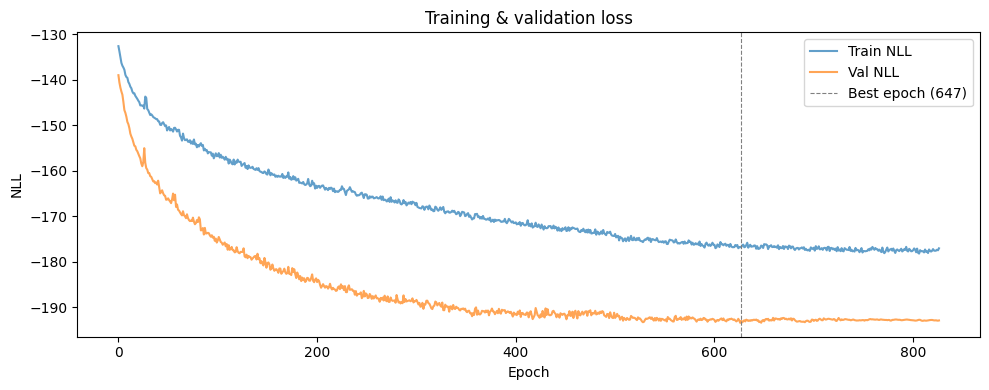

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
skip = 20  # skip initial transient
ax.plot(result.train_losses[skip:], label="Train NLL", alpha=0.7)
ax.plot(result.val_losses[skip:], label="Val NLL", alpha=0.7)
ax.axvline(result.best_epoch - skip, color="gray", ls="--", lw=0.8, label=f"Best epoch ({result.best_epoch})")
ax.set(xlabel="Epoch", ylabel="NLL", title="Training & validation loss")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Evaluation

Visual and statistical checks to verify that generated scenarios are realistic.

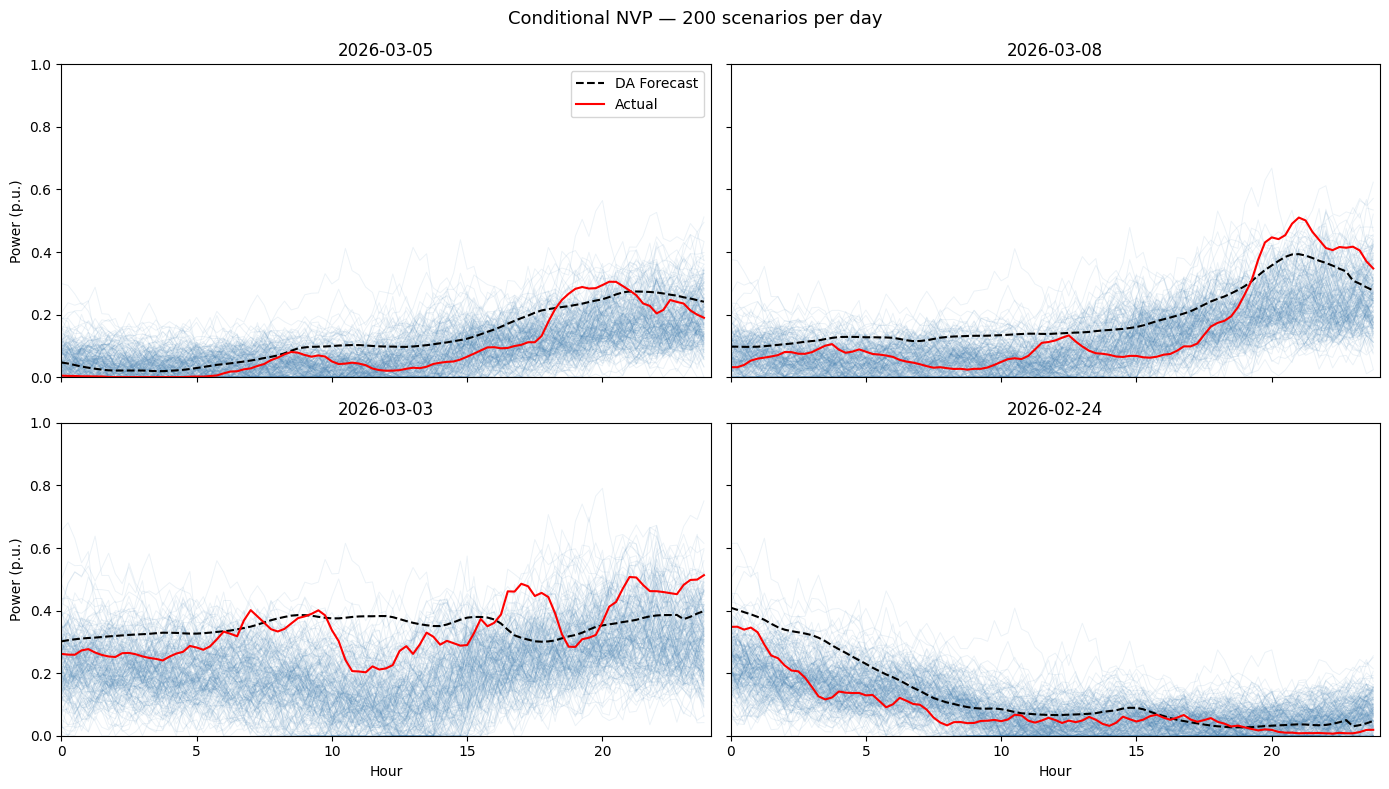

In [ ]:
# Fan plots: 200 scenarios vs actual production for 4 random test days
model.eval()
n_scenarios = 200
hours = np.arange(N_STEPS) * 0.25

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, idx in zip(axes.flat, np.random.choice(len(X_prod_test), size=4, replace=False)):
    forecast = torch.tensor(X_fcst_test[idx], dtype=torch.float32)
    scenarios = model.sample(forecast, n_samples=n_scenarios, seed=42).cpu().numpy().clip(0, 1)

    for s in scenarios:
        ax.plot(hours, s, color="steelblue", alpha=0.1, lw=0.7)
    ax.plot(hours, X_fcst_test[idx], "k--", lw=1.5, label="DA Forecast")
    ax.plot(hours, X_prod_test[idx], "r-", lw=1.5, label="Actual")
    ax.set_title(f"{dates_test[idx]}")
    ax.set(xlim=(0, 24), ylim=(0, 1))

axes[0, 0].legend(loc="upper right")
axes[1, 0].set_xlabel("Hour"); axes[1, 1].set_xlabel("Hour")
axes[0, 0].set_ylabel("Power (p.u.)"); axes[1, 0].set_ylabel("Power (p.u.)")
fig.suptitle(f"Conditional NVP — {n_scenarios} scenarios per day", fontsize=13)
plt.tight_layout()
plt.show()

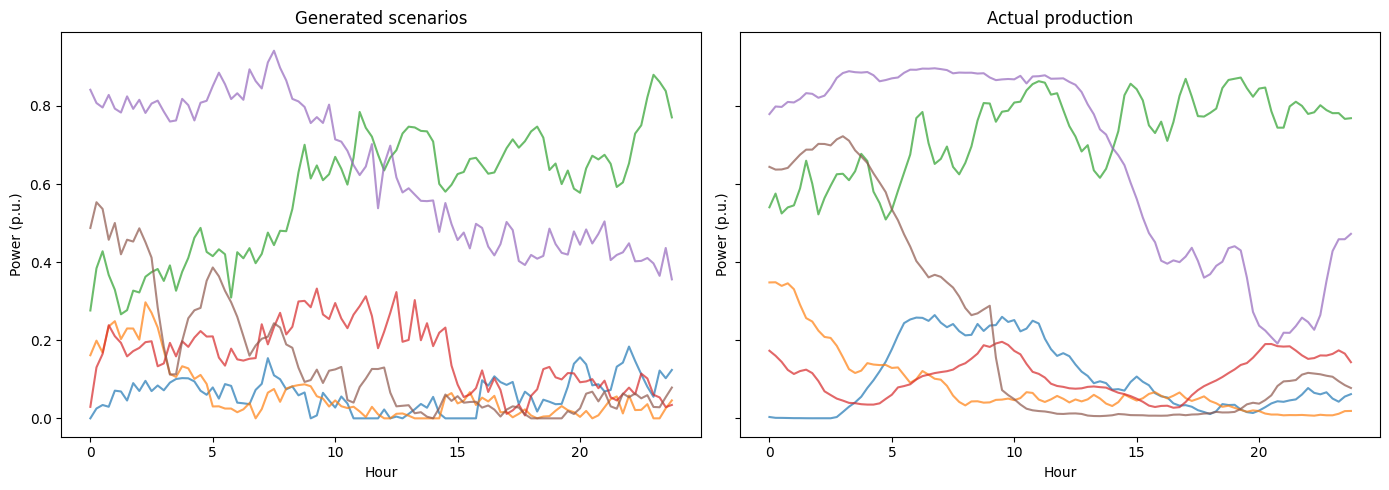

In [ ]:
# Side-by-side: generated vs real daily profiles
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for idx in np.random.choice(len(X_prod_test), size=6, replace=False):
    forecast = torch.tensor(X_fcst_test[idx], dtype=torch.float32)
    scenario = model.sample(forecast, n_samples=1, seed=idx).cpu().numpy().clip(0, 1)[0]
    axes[0].plot(hours, scenario, alpha=0.7)
    axes[1].plot(hours, X_prod_test[idx], alpha=0.7)

axes[0].set(title="Generated scenarios", xlabel="Hour", ylabel="Power (p.u.)")
axes[1].set(title="Actual production", xlabel="Hour", ylabel="Power (p.u.)")
plt.tight_layout()
plt.show()

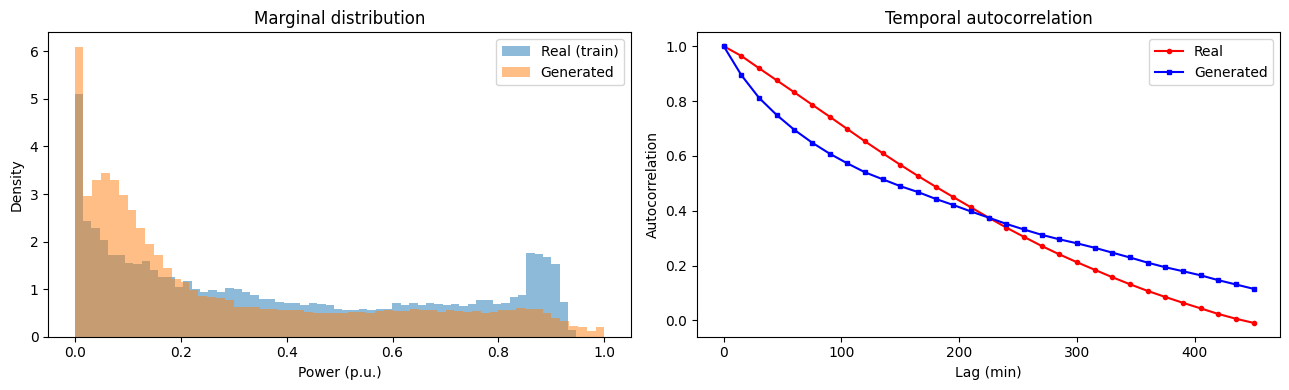

In [ ]:
# Generate a pool of scenarios from all test forecasts for statistical comparison
all_scenarios = []
for i in range(len(X_fcst_test)):
    fc = torch.tensor(X_fcst_test[i], dtype=torch.float32)
    s = model.sample(fc, n_samples=20, seed=i).cpu().numpy().clip(0, 1)
    all_scenarios.append(s)
all_scenarios = np.concatenate(all_scenarios, axis=0)

# --- Marginal distribution & autocorrelation ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Marginal distribution of power values
axes[0].hist(X_prod_train.ravel(), bins=60, density=True, alpha=0.5, label="Real (train)")
axes[0].hist(all_scenarios.ravel(), bins=60, density=True, alpha=0.5, label="Generated")
axes[0].set(xlabel="Power (p.u.)", ylabel="Density", title="Marginal distribution")
axes[0].legend()

# Temporal autocorrelation
def autocorr(X, max_lag=30):
    ac = [1.0]
    for lag in range(1, max_lag + 1):
        vals = [np.corrcoef(row[:-lag], row[lag:])[0, 1] for row in X]
        ac.append(np.nanmean(vals))
    return np.array(ac)

lags = np.arange(31) * 15  # minutes
axes[1].plot(lags, autocorr(X_prod_train), "r-o", ms=3, label="Real")
axes[1].plot(lags, autocorr(all_scenarios), "b-s", ms=3, label="Generated")
axes[1].set(xlabel="Lag (min)", ylabel="Autocorrelation", title="Temporal autocorrelation")
axes[1].legend()

plt.tight_layout()
plt.show()

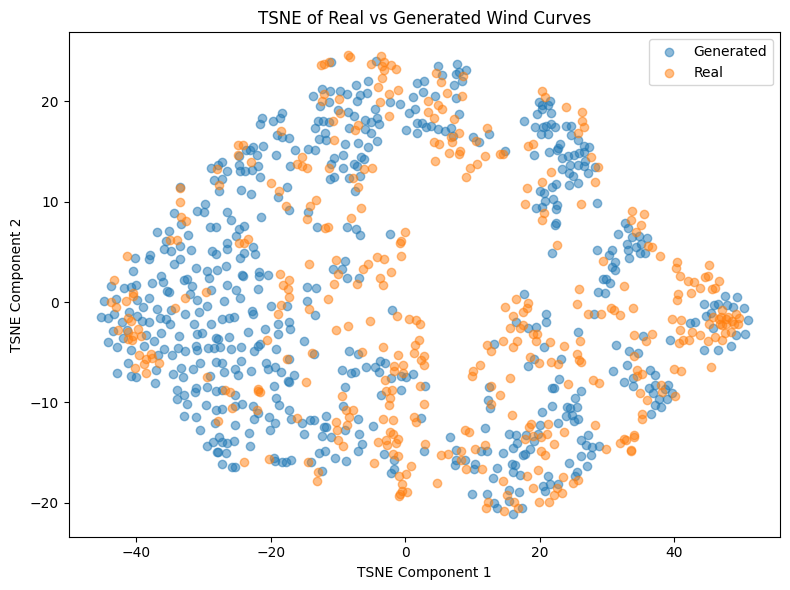

In [ ]:
# t-SNE embedding: real vs generated curves in 2D
from sklearn.manifold import TSNE

X_all = np.vstack([X_prod_train, all_scenarios])
labels = np.array(["Real"] * len(X_prod_train) + ["Generated"] * len(all_scenarios))
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_all)

plt.figure(figsize=(8, 6))
for label in ["Real", "Generated"]:
    mask = labels == label
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.5, label=label, s=15)
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("t-SNE: Real vs Generated Wind Curves")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Save Trained Model

Save the state dict to `trained_models/wind_generation/` so it can be loaded by `WindProductionGenerator`.

In [ ]:
save_path = "../trained_models/wind_generation/conditional_nvp.pt"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to ../models/conditional_nvp.pt
